In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
titanic=sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [4]:
features=["pclass","sex","embarked","age"]
target=["survived"]

In [5]:
#Filling null values
from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy='median')
titanic[["age"]]=imp_median.fit_transform(titanic[["age"]])


imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])



#SimpleImputer replaces those NaN values automatically.
# simplerimputer always requires 2-d array therefore double square brackets

In [6]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])


In [7]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [8]:
X=titanic[features]
y=titanic[target]

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [10]:
from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier()
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [11]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)

print("accuracy: ", accuracy_score(y_test, y_pred))

accuracy:  0.7322033898305085


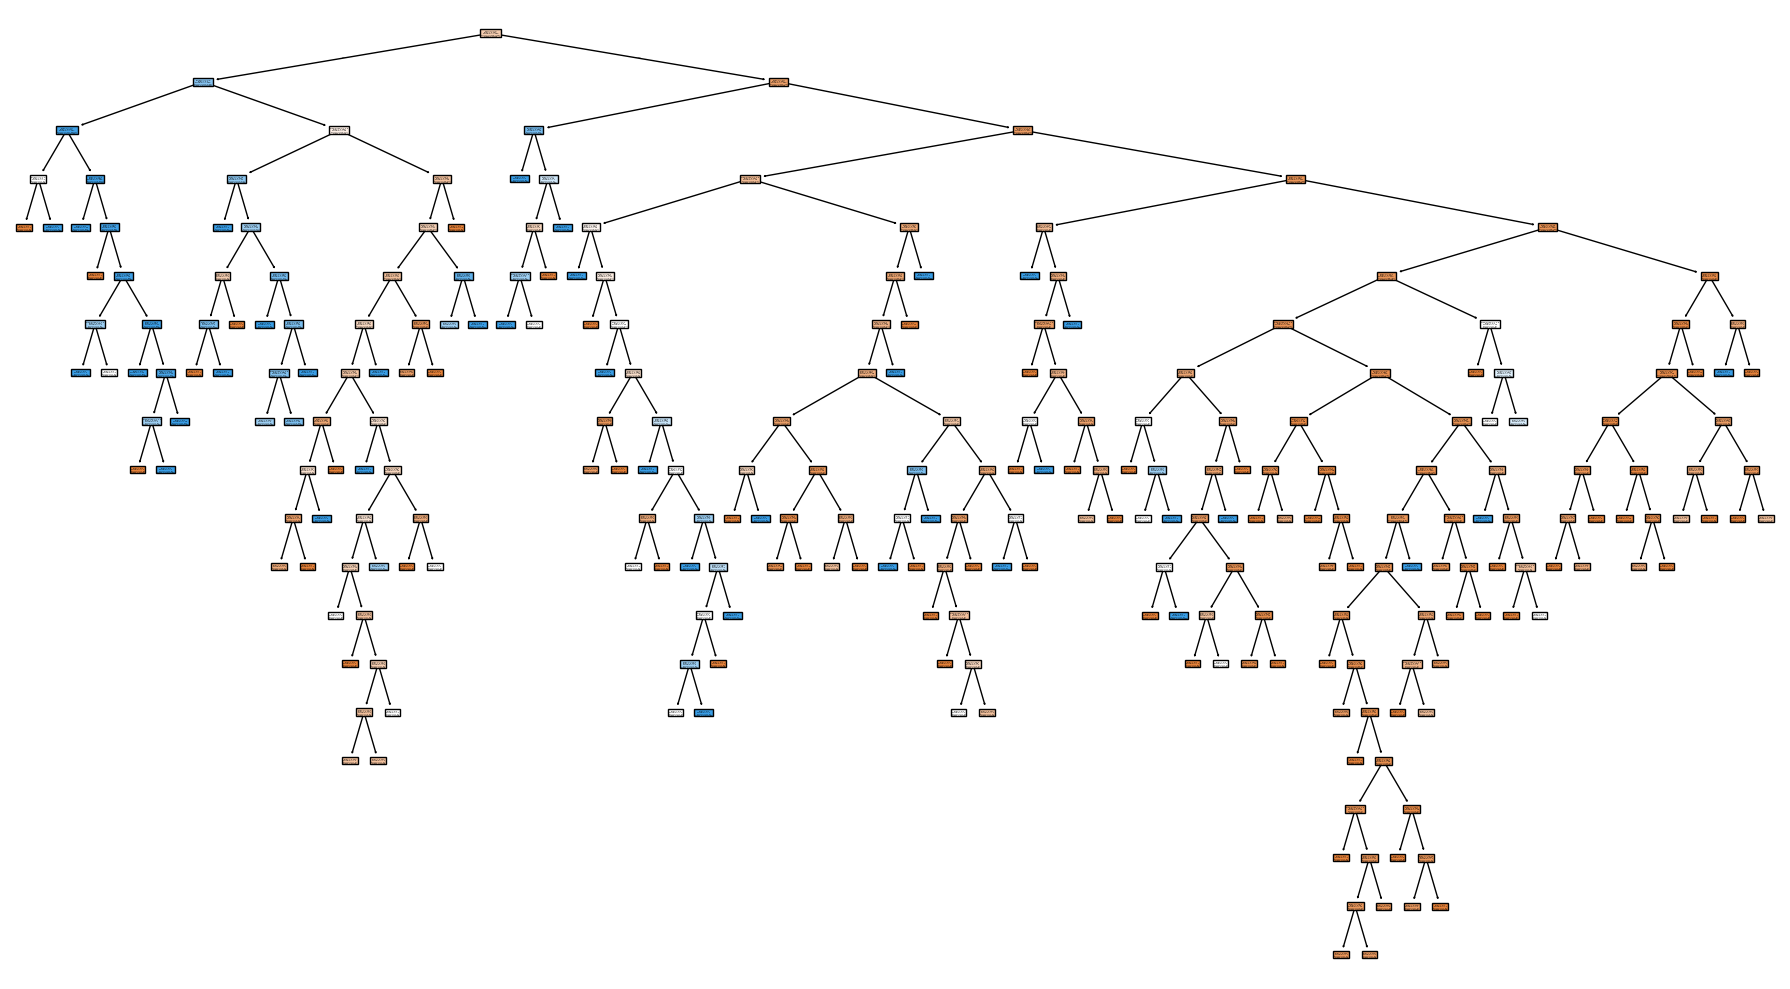

In [12]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True
    
)

plt.tight_layout()
plt.show()

##  Pre-Pruning 

###  🎯 Most Important Ones

### ✅ max_depth

### ✅ min_samples_split

### ✅ min_samples_leaf

### These control overfitting the most.

In [13]:
# how to find perfect depth and samples_split
max_depth=[2,3,4,5,6,7,8,9,10]

for depth in max_depth:
    model=DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train,y_train)

    acc = model.score(X_test, y_test)
    print(f"for depth={depth}, accuracy={acc}")

# same for min_samples_split=[10,20,30,40,50,60]

for depth=2, accuracy=0.7762711864406779
for depth=3, accuracy=0.8033898305084746
for depth=4, accuracy=0.8101694915254237
for depth=5, accuracy=0.7830508474576271
for depth=6, accuracy=0.7966101694915254
for depth=7, accuracy=0.7728813559322034
for depth=8, accuracy=0.7593220338983051
for depth=9, accuracy=0.7661016949152543
for depth=10, accuracy=0.7186440677966102


In [14]:
#With pre-pruning

In [15]:
model=DecisionTreeClassifier(max_depth=4,min_samples_split=10)
model.fit(X_train,y_train)

#we can use GridSearchCV to decide min_sample_split 
#but here i have taken a random value bases on the size of the data
set

DecisionTreeClassifier(max_depth=4, min_samples_split=10)

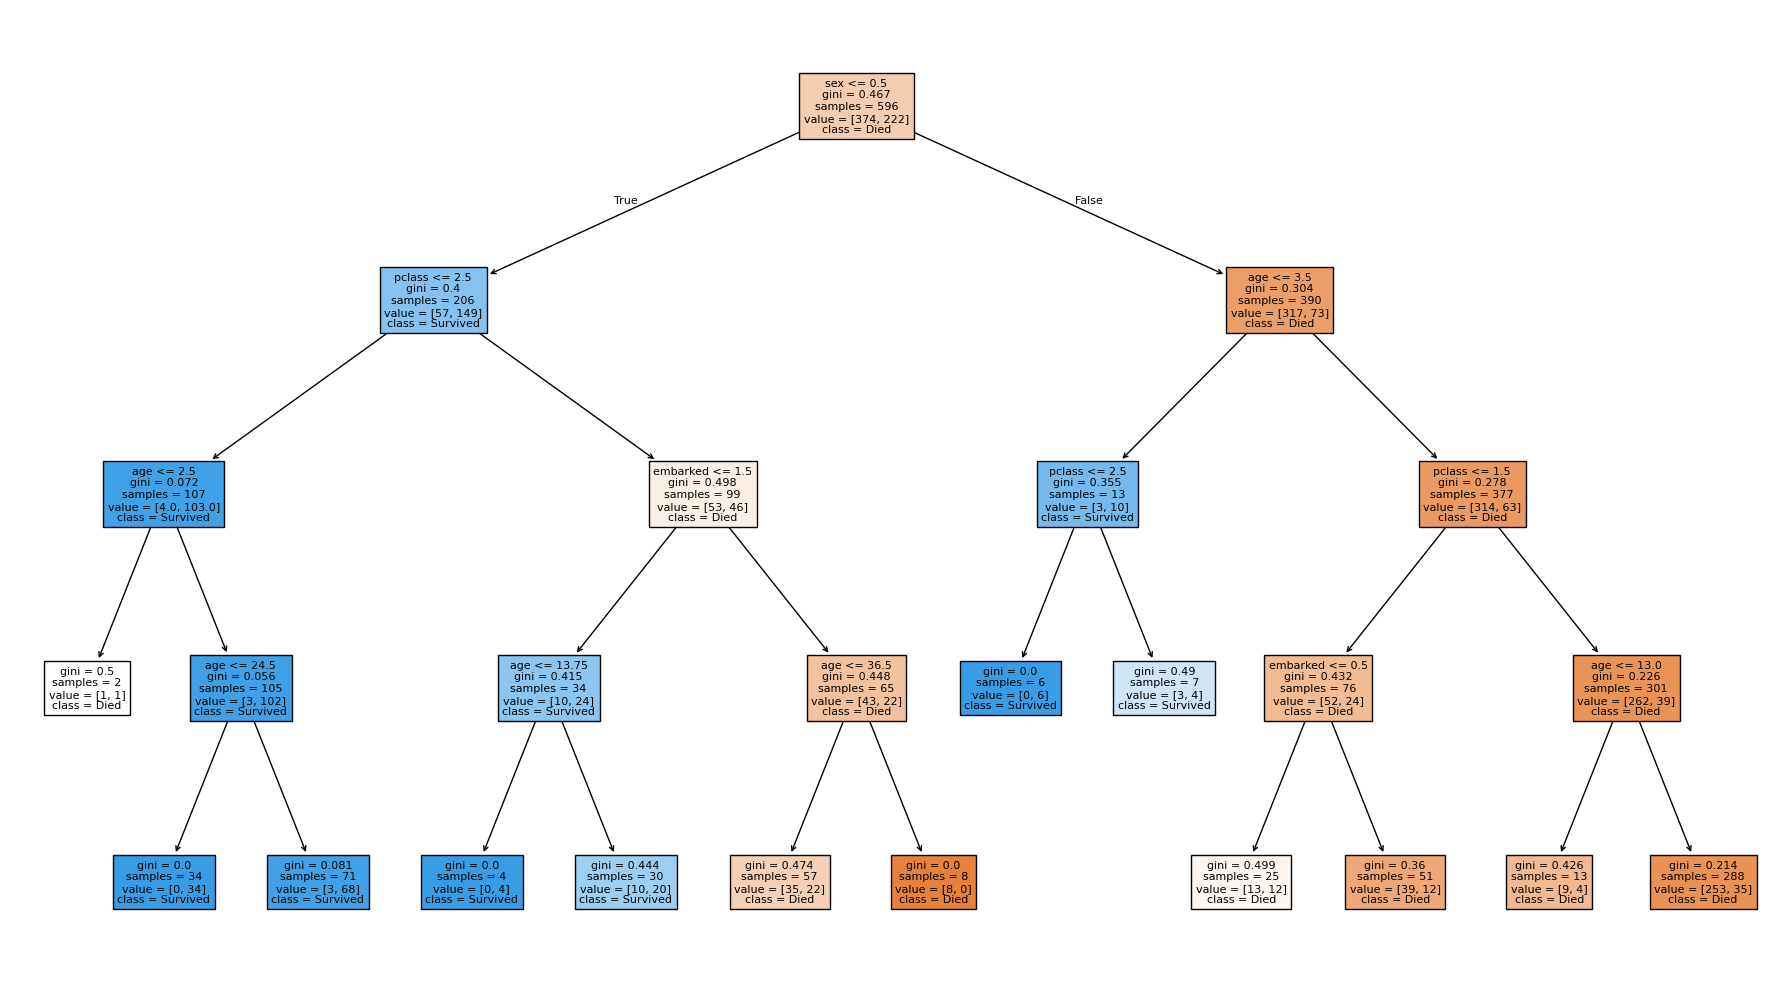

In [16]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True
   
)

plt.tight_layout()
plt.show()

In [17]:
acc = model.score(X_test, y_test)
print(f" Accuracy={acc*100}%")

 Accuracy=80.33898305084746%


### Post -Pruning

## What is Cost Complexity Pruning?

This is post-pruning.

Instead of stopping early (pre-pruning), we:

Grow a full tree

Then cut branches gradually

The cutting is controlled by `ccp_alpha`


In [18]:
full_tree =DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [19]:
path=full_tree.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas=path.ccp_alphas
print(ccp_alphas)


[0.00000000e+00 0.00000000e+00 6.14597930e-06 1.38284534e-05
 1.52532032e-05 1.69480035e-05 2.15109276e-05 5.59284116e-05
 5.88720122e-05 7.98977309e-05 7.98977309e-05 1.07611783e-04
 1.11856823e-04 1.25057318e-04 1.26504741e-04 1.39821029e-04
 1.47690555e-04 1.67785235e-04 1.67785235e-04 2.20770046e-04
 2.23713647e-04 2.51677852e-04 2.61483483e-04 2.79642058e-04
 2.79642058e-04 2.79642058e-04 2.79642058e-04 3.01719063e-04
 3.02770349e-04 3.38797109e-04 3.68619077e-04 3.81330079e-04
 4.08636592e-04 4.47427293e-04 5.08440106e-04 5.16541624e-04
 5.48528653e-04 5.59284116e-04 5.59284116e-04 5.59284116e-04
 5.59284116e-04 5.59284116e-04 5.59284116e-04 6.22382837e-04
 6.39181847e-04 7.45712155e-04 8.38926174e-04 9.15192190e-04
 9.35529795e-04 1.07062959e-03 1.11856823e-03 1.12639039e-03
 1.15052733e-03 1.18766074e-03 1.25042334e-03 1.25838926e-03
 1.39821029e-03 1.49667580e-03 1.60034408e-03 1.75775008e-03
 1.90078378e-03 1.99129729e-03 2.03786212e-03 2.06895174e-03
 2.07365342e-03 2.146031

In [20]:
#train our model for all alphas

trees=[]
for alpha in ccp_alphas:
    model=DecisionTreeClassifier(random_state=42,ccp_alpha=alpha)
    model.fit(X_train,y_train)

In [21]:
best_alpha=0
best_acc=0

for model,alpha in trees:
    curr_acc=model.score(X_test,y_test)
    if curr_acc >best_acc:
        best_acc=curr_acc
        best_alpha=alpha


In [22]:
best_model=DecisionTreeClassifier(ccp_alpha=best_alpha)
best_model.fit(X_train,y_train)

DecisionTreeClassifier(ccp_alpha=0)

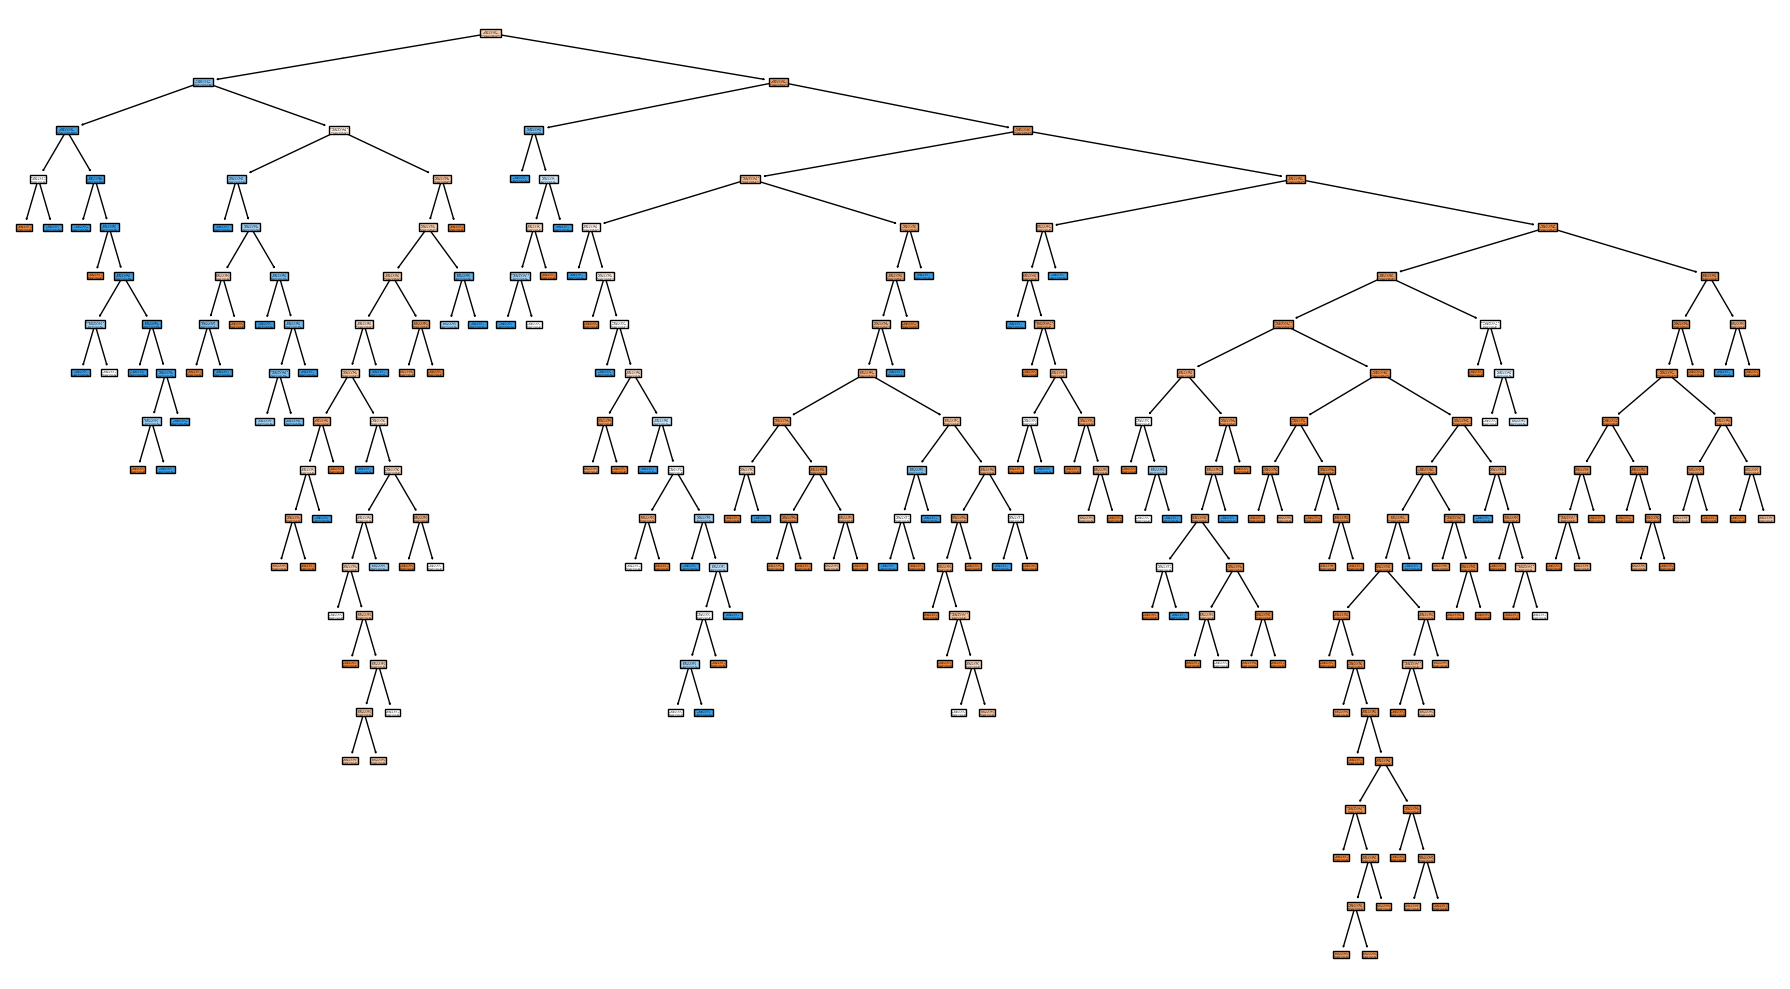

In [23]:

plt.figure(figsize=(18, 10))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True
   
)

plt.tight_layout()
plt.show()